# Function 6 - Week 3: output review

Review the latest result, then move to model predictions to choose the next query.


In [1]:
# Imports & shared helpers
import pandas as pd
from pathlib import Path
import sys

shared_dir = next(
    (folder / "Shared"
     for folder in (Path.cwd(), *Path.cwd().parents)
     if (folder / "Shared" / "plot_helpers.py").is_file()),
    None,
)
if shared_dir is None:
    raise FileNotFoundError("Run this notebook from within the notebooks folder.")
if str(shared_dir) not in sys.path:
    sys.path.insert(0, str(shared_dir))

from plot_helpers import plot_output_distribution
from output_helpers import summarise_output_observations
from query_budget import remaining_queries, TOTAL_QUERY_WEEKS


In [2]:
# Data and output paths for this week's notebook.
# Start the kernel with this notebook's folder as its working directory.
week_dir = Path.cwd().resolve()
full_data_path = week_dir / "observations.csv"

if not (week_dir / "exploration.ipynb").is_file() or not full_data_path.is_file():
    raise FileNotFoundError(
        "Run this notebook with its own folder as the working directory; "
        "exploration.ipynb and observations.csv must be together."
    )

figures = week_dir / "figures"
figures.mkdir(parents=True, exist_ok=True)



In [3]:
# Basic data load
print(f"Loading data from: {full_data_path}")
data = pd.read_csv(full_data_path)

Loading data from: C:\_Source\Imperial-ML-AI-Live\Capstone\imperial-capstone\stage-2-bbo\notebooks\Function_6\Week_03\observations.csv


In [4]:
# Column inspection
columns = data.columns
print("Columns: ", columns)

Columns:  Index(['observation_id', 'source_round', 'x1', 'x2', 'x3', 'x4', 'x5', 'y'], dtype='str')


In [5]:
# Where we pray for good data, aka checking for nulls
print (data.isna().sum())

observation_id    0
source_round      0
x1                0
x2                0
x3                0
x4                0
x5                0
y                 0
dtype: int64


In [6]:
# Splitting our data into inputs X and outputs y
output_column = "y"
# The course names inputs x1, x2, ...; preserve their CSV column order.
input_columns = [
    name for name in data.columns
    if name.startswith("x") and name[1:].isdigit()
]

#print("Input columns: ", input_columns)
#print("Output column: ", output_column)

X = data[input_columns]
y = data[output_column]

#print("The inputs are given by :")
#print(X.head())
#print("The outputs are given by :")
#print(y[:5])


In [7]:
# Review the latest recorded submission against earlier observed outputs.
output_review = summarise_output_observations(
    data,
    input_columns=input_columns,
    output_column=output_column,
)
print(output_review["report"])


Latest recorded submission: round 2 (1 new output).
Compared with 21 earlier observations (22 outputs in total).
Earlier output range: [-2.57116963161, -0.378691254548].

round-02: y = -1.12428079278 (negative); rank 5/22 (1 = highest output).
Inputs: x1 = 0.207231, x2 = 0.508312, x3 = 0.102836, x4 = 0.929415, x5 = 0
Within the earlier output range.


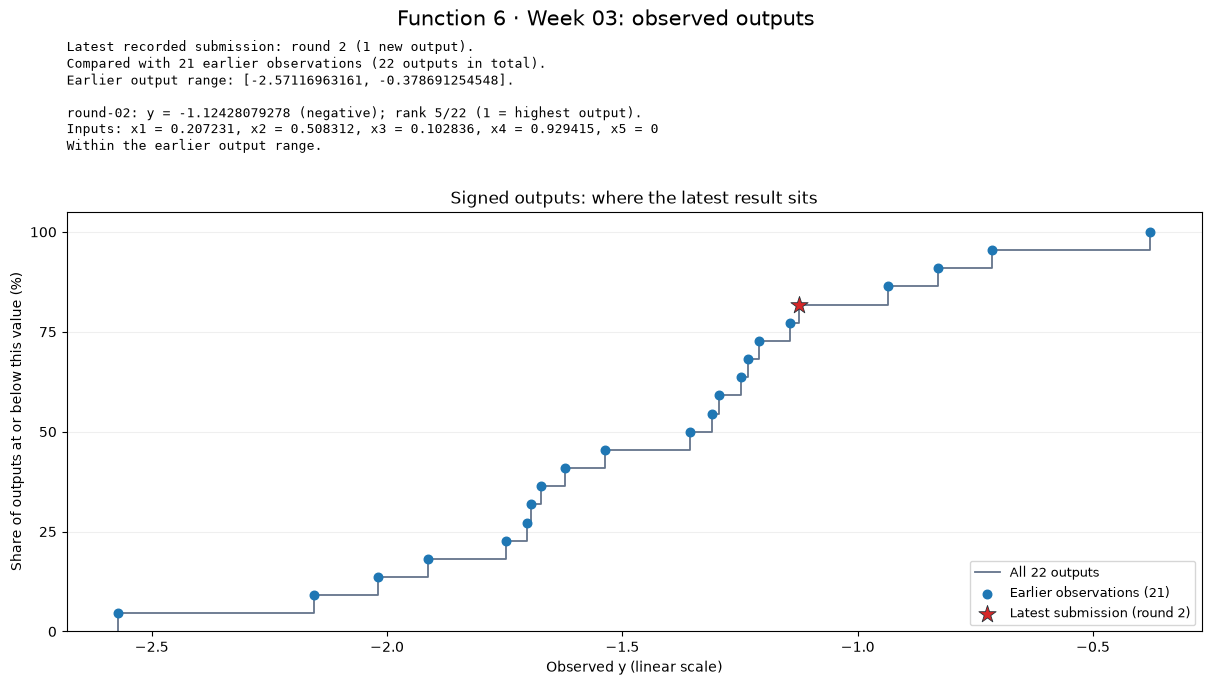

In [8]:
# Show every output, highlight the latest result and save a chart for the weekly write-up.
plot_output_distribution(
    output_review,
    title=f"{week_dir.parent.name.replace('_', ' ')} · {week_dir.name.replace('_', ' ')}: observed outputs",
    save_to=figures / "output-distribution.png",
)


In [9]:
# Initial observations do not consume the weekly query allowance.
initial_observations = int((data["source_round"] == 0).sum())
confirmed_queries = int((data["source_round"] > 0).sum())
print(f"Observations: {len(data)} ({initial_observations} initial + {confirmed_queries} returned queries)")
print(f"Weekly queries used: {confirmed_queries}/{TOTAL_QUERY_WEEKS}")
print(f"Queries available from the start of this week: {remaining_queries(week_dir)}")


Observations: 22 (20 initial + 2 returned queries)
Weekly queries used: 2/13
Queries available from the start of this week: 11


## Next step: model predictions

The latest output is **-1.124281**, ranked **5/22 (1 = highest output)**. It is within the earlier range; the best remains **-0.378691**.
The [saved Week 2 forecast](../Week_02/model_predictions.ipynb) was **-0.641226**; the returned value was **0.483055** lower.

That query was selected partly for uncertainty, with a predicted mean below the best. Continue in [model predictions](model_predictions.ipynb): update the model, check held-out performance and sensitivity, and choose one query before reassessing.
